In [2]:
import os
import ast
import pandas as pd
import matplotlib.pyplot as plt
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import json
import reprlib
import seaborn as sns
import numpy as np

In [3]:
df = pd.read_csv('../preprocessing/cleaned_text.csv')
df.head()

,full_text,case_folding,tokens,normalized,stopword_removal,stemming
0,Chale Your man start dey do Crypto Football ay...,chale your man start dey do crypto football ay...,"['chale', 'your', 'man', 'start', 'dey', 'do',...","['chale', 'your', 'man', 'start', 'dey', 'di',...","['chale', 'man', 'start', 'dey', 'crypto', 'fo...","['chale', 'man', 'start', 'dey', 'crypto', 'fo..."
1,Bitcoin Orange OGsatoshis,bitcoin orange ogsatoshis,"['bitcoin', 'orange', 'ogsatoshis']","['bitcoin', 'orange', 'ogsatoshis']","['bitcoin', 'orange', 'ogsatoshis']","['bitcoin', 'orange', 'ogsatoshis']"
2,WahyuS Problem terbesar yg diselesaikan web ad...,wahyus problem terbesar yg diselesaikan web ad...,"['wahyus', 'problem', 'terbesar', 'yg', 'disel...","['wahyus', 'problem', 'terbesar', 'yang', 'dis...","['wahyus', 'problem', 'terbesar', 'diselesaika...","['wahyus', 'problem', 'besar', 'selesai', 'web..."
3,Buat ngejelasin ke boomer yang bilang Underwea...,buat ngejelasin ke boomer yang bilang underwea...,"['buat', 'ngejelasin', 'ke', 'boomer', 'yang',...","['buat', 'menjelaskan', 'ke', 'boomer', 'yang'...","['boomer', 'bilang', 'underwear', 'eh', 'under...","['boomer', 'bilang', 'underwear', 'eh', 'under..."
4,Ek aisi wife to main bhi deserve karta hu yaar,ek aisi wife to main bhi deserve karta hu yaar,"['ek', 'aisi', 'wife', 'to', 'main', 'bhi', 'd...","['ek', 'aisi', 'wife', 'tapi', 'main', 'bhi', ...","['ek', 'aisi', 'wife', 'main', 'bhi', 'deserve...","['ek', 'aisi', 'wife', 'main', 'bhi', 'deserve..."


In [4]:
df.drop(columns=['full_text', 'case_folding', 'tokens', 'normalized', 'stopword_removal'], inplace=True)
df

,stemming
0,"['chale', 'man', 'start', 'dey', 'crypto', 'fo..."
1,"['bitcoin', 'orange', 'ogsatoshis']"
2,"['wahyus', 'problem', 'besar', 'selesai', 'web..."
3,"['boomer', 'bilang', 'underwear', 'eh', 'under..."
4,"['ek', 'aisi', 'wife', 'main', 'bhi', 'deserve..."
...,...
1231,"['raja', 'mata', 'uang', 'crypto', 'bitcoin', ..."
1232,"['ktk', 'kampuni', 'zenye', 'market', 'cap', '..."
1233,"['meinmokhtar', 'hang', 'keje', 'penuh', 'asb'..."
1234,"['join', 'gabung', 'ajar', 'santuy', 'bareng',..."


In [5]:
# Cek data duplikat
print(f"Jumlah data duplikat: {df.duplicated().sum()}")

# Cek data kosong
print(f"Jumlah data kosong: {df.isnull().sum().sum()}")

# Tampilkan data yang duplikat
duplicate_data = df[df.duplicated()]
print("Data duplikat:")
print(duplicate_data)
# menghapus data duplikat
df.drop_duplicates(inplace=True)
print(f'Jumlah data duplikat: {df.duplicated().sum()}')
print(f"Jumlah data setelah menghapus duplikat: {len(df)}")

Jumlah data duplikat: 67
Jumlah data kosong: 0
Data duplikat:
                                               stemming
36    ['umum', 'umum', 'harga', 'bitcoin', 'rp', 'mi...
62    ['umum', 'umum', 'harga', 'bitcoin', 'rp', 'mi...
74    ['umum', 'umum', 'harga', 'bitcoin', 'rp', 'mi...
114   ['umum', 'umum', 'harga', 'bitcoin', 'rp', 'mi...
125   ['umum', 'umum', 'harga', 'bitcoin', 'rp', 'mi...
...                                                 ...
1138                  ['yokai', 'btc', 'yokaiavengers']
1142                                            ['btc']
1147  ['umum', 'umum', 'harga', 'bitcoin', 'rp', 'mi...
1167  ['umum', 'umum', 'harga', 'bitcoin', 'rp', 'mi...
1223  ['umum', 'umum', 'harga', 'bitcoin', 'rp', 'mi...

[67 rows x 1 columns]
Jumlah data duplikat: 0
Jumlah data setelah menghapus duplikat: 1169


In [6]:
# Proses Pelabelan dengan InSet
pos_inset = pd.read_csv(
    '../../InSet/positive.tsv', 
    sep='\t', 
    header=0, 
    dtype={'weight': float},
    on_bad_lines='skip'
)

neg_inset = pd.read_csv(
    '../../InSet/negative.tsv', 
    sep='\t', 
    header=0, 
    dtype={'weight': float},
    on_bad_lines='skip'
)

# Opsional: Standarisasi nama kolom dan hapus data kosong (NaN) untuk keamanan
pos_inset.columns = ['word', 'weight']
neg_inset.columns = ['word', 'weight']
pos_inset = pos_inset.dropna()
neg_inset = neg_inset.dropna()

# Konversi ke dictionary dan ubah ke lowercase agar pencarian case-insensitive
pos_inset_dict = {str(row['word']).lower(): float(row['weight']) for _, row in pos_inset.iterrows()}
neg_inset_dict = {str(row['word']).lower(): float(row['weight']) for _, row in neg_inset.iterrows()}


# ==========================================
# 2. FUNGSI PELABELAN
# ==========================================
def label_inset(tokens, pos_dict, neg_dict):
    skor = 0.0
    words_found = []
    
    # Keamanan: Pastikan 'tokens' adalah list. 
    if isinstance(tokens, str):
        try:
            tokens = ast.literal_eval(tokens)
        except (ValueError, SyntaxError):
            tokens = str(tokens).split() # Fallback: pisahkan berdasarkan spasi

    for word in tokens:
        word_lower = str(word).lower()
        
        if word_lower in pos_dict:
            skor += pos_dict[word_lower]
            words_found.append(f"{word_lower}({pos_dict[word_lower]})")
            
        elif word_lower in neg_dict:
            skor += neg_dict[word_lower]
            words_found.append(f"{word_lower}({neg_dict[word_lower]})")
    
    # ==========================================
    # 3. PENENTUAN LABEL
    # ==========================================
    if skor > 0:
        label = 'positive'
        nilai_label = 1
    else:
        label = 'negative'
        nilai_label = -1

    return label, nilai_label, ", ".join(words_found)


# ==========================================
# 4. APLIKASIKAN KE DATAFRAME
# ==========================================
# Menggunakan list comprehension lebih stabil daripada zip(*)
results = df['stemming'].apply(lambda x: label_inset(x, pos_inset_dict, neg_inset_dict))

df['inset'] = [r[0] for r in results]
df['nilai_inset'] = [r[1] for r in results]
df['matched_words'] = [r[2] for r in results] # Kolom bantu untuk validasi

# Tampilkan 5 baris pertama
print(df[['stemming', 'inset', 'nilai_inset', 'matched_words']].head())

                                            stemming     inset  nilai_inset  \
0  ['chale', 'man', 'start', 'dey', 'crypto', 'fo...  negative           -1   
1                ['bitcoin', 'orange', 'ogsatoshis']  negative           -1   
2  ['wahyus', 'problem', 'besar', 'selesai', 'web...  negative           -1   
3  ['boomer', 'bilang', 'underwear', 'eh', 'under...  negative           -1   
4  ['ek', 'aisi', 'wife', 'main', 'bhi', 'deserve...  positive            1   

                                       matched_words  
0                                          man(-1.0)  
1                                                     
2  problem(-4.0), besar(4.0), selesai(2.0), risik...  
3                                                     
4                                          main(2.0)  


In [7]:
# Proses Pelabelan dengan SentiStrengthID
sia = SentimentIntensityAnalyzer()
sia.lexicon.clear()

with open('../../sentistrength_id/_json_sentiwords_id.txt') as f:
    lexicon = f.read()

sentis = json.loads(lexicon)

sia.lexicon.update(sentis)
print(f"Jumlah kata dalam lexicon: {len(sia.lexicon)}")
print(reprlib.repr(sia.lexicon))

def is_positive_senti(tweet: str) -> bool:
    """True if tweet has positive compound sentiment, False otherwise."""
    return sia.polarity_scores(tweet)["compound"] > 0

# Menulis hasil label untuk setiap kalimat berdasarkan nilai compound dari SentiStrength
#Mengubah bentuk dataframe menjadi string(kalimat utuh)
df['stemming'] = [' '.join(eval(str)) for str in df['stemming'].values]

for tweet in df['stemming']:
    if is_positive_senti(tweet) == True:
        label = "positive"
    else:
        label = "negative"
    df.loc[df['stemming'] == tweet, 'senti'] = label

df

Jumlah kata dalam lexicon: 1729
{'abadi': 5, 'absen': -3, 'abu-abu': -1, 'acuh': 4, ...}


,stemming,inset,nilai_inset,matched_words,senti
0,chale man start dey crypto football ay kak aa ...,negative,-1,man(-1.0),negative
1,bitcoin orange ogsatoshis,negative,-1,,negative
2,wahyus problem besar selesai web risiko orang ...,negative,-1,"problem(-4.0), besar(4.0), selesai(2.0), risik...",positive
3,boomer bilang underwear eh underlyingnya bitcoin,negative,-1,,negative
4,ek aisi wife main bhi deserve karta hu yaar,positive,1,main(2.0),negative
...,...,...,...,...,...
1231,raja mata uang crypto bitcoin postingan halama...,negative,-1,"mata(-2.0), moga(1.0), tunggu(1.0), nanti(-2.0...",negative
1232,ktk kampuni zenye market cap kubwa duniani ora...,positive,1,"ya(4.0), ya(4.0), ya(4.0), ya(4.0)",negative
1233,meinmokhtar hang keje penuh asb dah n asbn bal...,positive,1,"dah(-3.0), joli(1.0), beli(2.0), rumah(3.0), c...",positive
1234,join gabung ajar santuy bareng cryptorize mala...,positive,1,"join(1.0), gabung(-5.0), ajar(1.0), bareng(3.0...",positive


In [8]:
df.drop(columns=['nilai_inset', 'matched_words'], inplace=True)
df

,stemming,inset,senti
0,chale man start dey crypto football ay kak aa ...,negative,negative
1,bitcoin orange ogsatoshis,negative,negative
2,wahyus problem besar selesai web risiko orang ...,negative,positive
3,boomer bilang underwear eh underlyingnya bitcoin,negative,negative
4,ek aisi wife main bhi deserve karta hu yaar,positive,negative
...,...,...,...
1231,raja mata uang crypto bitcoin postingan halama...,negative,negative
1232,ktk kampuni zenye market cap kubwa duniani ora...,positive,negative
1233,meinmokhtar hang keje penuh asb dah n asbn bal...,positive,positive
1234,join gabung ajar santuy bareng cryptorize mala...,positive,positive


In [9]:
# jumlah data positif dan negatif
print(df['inset'].value_counts())
print(df['senti'].value_counts())


inset
negative    616
positive    553
Name: count, dtype: int64
senti
negative    896
positive    273
Name: count, dtype: int64


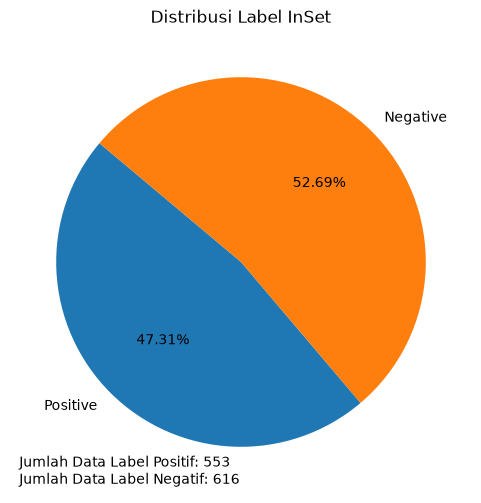

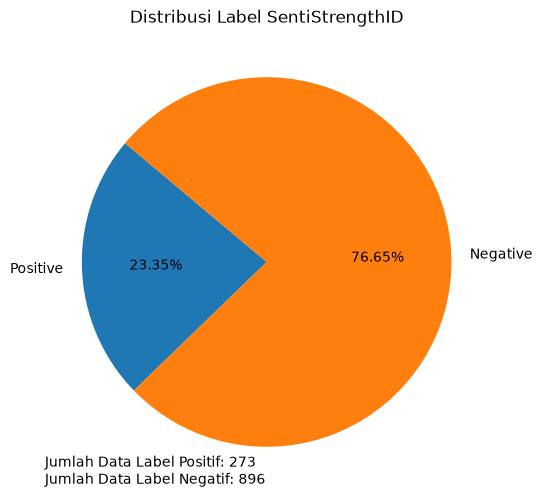

In [10]:
pos1 = df['inset'].value_counts().get('positive', 0)
neg1 = df['inset'].value_counts().get('negative', 0)

pos2 = df['senti'].value_counts().get('positive', 0)
neg2 = df['senti'].value_counts().get('negative', 0)

label_inset = ['Positive', 'Negative']
size_inset = [pos1, neg1]
plt.figure(figsize=(6, 6))
plt.pie(size_inset, labels=label_inset, autopct='%1.2f%%', startangle=140)
plt.text(-1.2, -1.2, f'Jumlah Data Label Positif: {pos1}\nJumlah Data Label Negatif: {neg1}', ha='left', fontsize=10)
plt.title('Distribusi Label InSet')
plt.show()

label_senti = ['Positive', 'Negative']
size_senti = [pos2, neg2]
plt.figure(figsize=(6, 6))
plt.pie(size_senti, labels=label_senti, autopct='%1.2f%%', startangle=140)
plt.text(-1.2, -1.2, f'Jumlah Data Label Positif: {pos2}\nJumlah Data Label Negatif: {neg2}', ha='left', fontsize=10)
plt.title('Distribusi Label SentiStrengthID')
plt.show()

In [11]:
df.to_csv('3_labeled_data.csv', index=False)

In [ ]:
# Kappa Score
from sklearn.metrics import cohen_kappa_score

y1 = df['inset']
y2 = df['senti']

label_mapping = {'positive': 1, 'negative': -1}

kappa_score = cohen_kappa_score(y1.map(label_mapping), y2.map(label_mapping))
print(f"Cohen's Kappa Score: {kappa_score:.4f}")

kappa_score = cohen_kappa_score(y1, y2, labels=['positive', 'negative'])
print(f"Cohen's Kappa Score: {kappa_score:.4f}")

Cohen's Kappa Score: 0.3130
Cohen's Kappa Score: 0.3130
